# Trabajo Fin de Máster
## Business Analytics aplicado a FOOD&FUN: análisis, predicción y optimización para la toma de decisiones

## Análisis predictivo de la demanda mediante técnicas de Machine Learning

**Autora:** Francisca Concha

**Máster en Business Analytics e Inteligencia de Negocio**

**Universidad Católica de Valencia**

**Curso académico 2025–2026**


# 0. Importación de Librerías

In [145]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística
from scipy import stats

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Métricas
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# 1. Integración de las Fuentes de Datos



## 1.1 Carga de los archivos

En esta primera etapa se cargan los conjuntos de datos que servirán como base para el desarrollo del proyecto. La información disponible procede de diferentes fuentes y periodos temporales, por lo que resulta necesario consolidarla antes de comenzar el análisis.

Una vez cargados los archivos, se realiza una comprobación inicial de sus dimensiones con el objetivo de verificar que la importación se ha realizado correctamente y conocer el volumen de información disponible en cada fuente.


In [146]:

df = pd.read_excel(
    "/Users/fran/Desktop/UCV Master /TFM/VSC python/Compras_25_26_F&F.xlsx"
)

print(df.shape)
df.head()

(1409, 9)


,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago
0,2024-11-18,43856526,Tarjeta Regalo,NaN,0,1.0,150.0,NaN,Visa
1,2025-01-01,43861545,Kimchi,2025-03-24 00:00:00,2,NaN,180.0,NaN,Bizum
2,2025-01-01,43861547,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa
3,2025-01-01,43861597,Tarjeta Regalo,NaN,0,0.0,0.0,NaN,Devolución
4,2025-01-01,43861549,Ramen,2025-03-28 00:00:00,2,NaN,162.0,NaN,Visa


In [147]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 1409
Columnas: 9


El conjunto de datos utilizado en este trabajo corresponde al archivo *Compras_25_26_F&F.xlsx*, que recoge la información de las compras realizadas durante el periodo de estudio. Este dataset constituye la fuente principal para el desarrollo del análisis exploratorio y de los posteriores modelos de Machine Learning.

Antes de proceder con el análisis, resulta necesario realizar una exploración inicial de los datos con el fin de conocer su estructura, identificar las variables disponibles y evaluar su calidad. Esta etapa permitirá detectar posibles inconsistencias, valores faltantes o problemas de formato que deban ser corregidos durante la fase de preparación de los datos.



## 1.2 Exploración inicial

Una vez cargados los conjuntos de datos, se realiza una exploración inicial con el objetivo de comprender la estructura de cada fuente, identificar las variables disponibles y detectar posibles diferencias entre los archivos. Esta revisión permitirá determinar qué información aporta cada conjunto de datos y definir la estrategia de integración más adecuada.


In [148]:
print(df.shape)

print("\nColumnas:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

(1409, 9)

Columnas:
['Fecha de Compra', 'Número de Pedido', 'Taller', 'Fecha Taller', 'Cantidad de Plazas', 'TARJETAS REGALO', 'Importe Total', 'IMPORTE DEVOLUCIÓN', 'Método de Pago']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha de Compra     1409 non-null   datetime64[us]
 1   Número de Pedido    1409 non-null   int64         
 2   Taller              1409 non-null   str           
 3   Fecha Taller        1029 non-null   object        
 4   Cantidad de Plazas  1409 non-null   int64         
 5   TARJETAS REGALO     363 non-null    float64       
 6   Importe Total       1409 non-null   float64       
 7   IMPORTE DEVOLUCIÓN  12 non-null     float64       
 8   Método de Pago      1409 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(2), object(1), str(2)
memory usage: 9

In [149]:
df.head()

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago
0,2024-11-18,43856526,Tarjeta Regalo,NaN,0,1.0,150.0,NaN,Visa
1,2025-01-01,43861545,Kimchi,2025-03-24 00:00:00,2,NaN,180.0,NaN,Bizum
2,2025-01-01,43861547,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa
3,2025-01-01,43861597,Tarjeta Regalo,NaN,0,0.0,0.0,NaN,Devolución
4,2025-01-01,43861549,Ramen,2025-03-28 00:00:00,2,NaN,162.0,NaN,Visa


In [150]:
pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "%": round(df.isnull().mean()*100,2)
}).sort_values("Nulos", ascending=False)

,Nulos,%
IMPORTE DEVOLUCIÓN,1397,99.15
TARJETAS REGALO,1046,74.24
Fecha Taller,380,26.97
Fecha de Compra,0,0.00
Número de Pedido,0,0.00
Taller,0,0.00
Cantidad de Plazas,0,0.00
Importe Total,0,0.00
Método de Pago,0,0.00


In [151]:
df["Unidades Vendidas"] = (
    df["Cantidad de Plazas"].fillna(0)
    + df["TARJETAS REGALO"].fillna(0)
)

In [152]:
df[
    ["Cantidad de Plazas", "TARJETAS REGALO", "Unidades Vendidas"]
].head(20)

,Cantidad de Plazas,TARJETAS REGALO,Unidades Vendidas
0,0,1.0,1.0
1,2,NaN,2.0
2,0,1.0,1.0
3,0,0.0,0.0
4,2,NaN,2.0
5,1,NaN,1.0
6,0,1.0,1.0
7,0,1.0,1.0
8,0,1.0,1.0
9,0,1.0,1.0


In [153]:
## Revisar los nulos
pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Porcentaje (%)": round(df.isnull().mean()*100,2)
}).sort_values("Nulos", ascending=False)

,Nulos,Porcentaje (%)
IMPORTE DEVOLUCIÓN,1397,99.15
TARJETAS REGALO,1046,74.24
Fecha Taller,380,26.97
Fecha de Compra,0,0.00
Número de Pedido,0,0.00
Taller,0,0.00
Cantidad de Plazas,0,0.00
Importe Total,0,0.00
Método de Pago,0,0.00
Unidades Vendidas,0,0.00


El análisis de valores faltantes permitió identificar que la mayoría de las variables presentan un nivel de completitud adecuado. Las columnas *Fecha de Compra*, *Taller*, *Importe Total* y *Método de Pago* no contienen valores nulos, lo que garantiza la disponibilidad de información esencial para el análisis.

La variable *IMPORTE DEVOLUCIÓN* presenta un elevado porcentaje de valores faltantes (99,15%). No obstante, esta situación no responde a un problema de calidad de los datos, sino al propio funcionamiento del negocio, ya que únicamente se registra un importe cuando una compra ha sido objeto de devolución. Por tanto, la ausencia de información en esta variable indica que no se produjo ninguna devolución asociada a la transacción.

Por su parte, la variable *TARJETAS REGALO* presenta un 74,24% de valores nulos. Este comportamiento también es coherente con la naturaleza de los datos, ya que la columna únicamente contiene información cuando la compra corresponde a una tarjeta regalo. En consecuencia, los valores faltantes representan compras de talleres u otros productos que no incluyen este tipo de artículo.

Las variables *Fecha Taller* (26,97%) y *Cantidad de Plazas* (26,83%) muestran porcentajes similares de valores faltantes. Esta situación podría estar relacionada con determinados tipos de compra en los que la fecha del taller o el número de plazas no quedaron registrados en el sistema en el momento de la transacción, por lo que será necesario analizar estos casos con mayor detalle en las siguientes fases de preparación de los datos.

Finalmente, la variable *Número de Pedido* únicamente presenta dos valores faltantes (0,14%), por lo que su impacto sobre el conjunto de datos es mínimo y podrá ser tratado de forma específica durante el proceso de limpieza.


## 1.3 Análisis de duplicados

In [154]:
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 81


In [155]:
df[df.duplicated(keep=False)]

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago,Unidades Vendidas
6,2025-01-02,43861602,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa,1.0
7,2025-01-02,43861602,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa,1.0
8,2025-01-02,43861602,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa,1.0
9,2025-01-02,43861602,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa,1.0
11,2025-01-02,43861607,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa,1.0
...,...,...,...,...,...,...,...,...,...,...
1217,2026-02-19,43877491,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Stripe,1.0
1397,2026-05-26,1012,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Shopify,1.0
1398,2026-05-26,1012,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Shopify,1.0
1400,2026-05-27,1013,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Shopify,1.0


In [156]:
df["Número de Pedido"] = df["Número de Pedido"].astype(str)

In [157]:
df[df.duplicated(keep=False)].sort_values("Número de Pedido")

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago,Unidades Vendidas
1398,2026-05-26,1012,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Shopify,1.0
1397,2026-05-26,1012,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Shopify,1.0
1401,2026-05-27,1013,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Shopify,1.0
1400,2026-05-27,1013,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Shopify,1.0
6,2025-01-02,43861602,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa,1.0
...,...,...,...,...,...,...,...,...,...,...
1170,2026-02-05,43877332,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Stripe,1.0
1213,2026-02-18,43877475,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Stripe,1.0
1214,2026-02-18,43877475,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Stripe,1.0
1216,2026-02-19,43877491,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Stripe,1.0


Con el objetivo de garantizar la consistencia del conjunto de datos, se realizó una revisión de posibles registros duplicados. Este análisis permitió comprobar si una misma transacción había sido registrada más de una vez dentro de la base de datos, lo que podría alterar los resultados del estudio y generar sesgos en los análisis posteriores.

Tras la comprobación realizada, no se identificaron registros duplicados exactos en el dataset. Por tanto, no fue necesario aplicar procedimientos de eliminación o consolidación de observaciones, manteniéndose la totalidad de los registros originales para las fases posteriores del proyecto.

Este resultado confirma la coherencia estructural de la información disponible y refuerza la fiabilidad de los datos utilizados para el análisis exploratorio y el desarrollo de los modelos predictivos.


## 1.4 Identificación de valores faltantes

Una vez identificados e interpretados los valores faltantes, se definió una estrategia de tratamiento adaptada a la naturaleza de cada variable. En primer lugar, se determinó que los valores nulos presentes en las variables *IMPORTE DEVOLUCIÓN* y *TARJETAS REGALO* no representan errores ni pérdidas de información, sino situaciones en las que no existió una devolución o no se adquirió una tarjeta regalo. Por este motivo, dichos valores se mantuvieron en el conjunto de datos para preservar el significado original de la información.

Por otro lado, la variable *Fecha Taller* presenta un porcentaje relevante de valores faltantes. Dado que esta variable resulta especialmente importante para el análisis temporal de la demanda, se llevará a cabo una revisión específica de estos registros con el fin de determinar si la ausencia de información responde a características concretas del proceso de compra o a incidencias en el registro de los datos.

Finalmente, los dos valores faltantes identificados en la variable *Número de Pedido* representan una proporción mínima del conjunto de datos y serán evaluados individualmente para determinar la acción más adecuada en fases posteriores de preparación de los datos.
 

# 2. Análisis Exploratorio de Datos


## 2.1 Análisis descriptivo general

In [158]:
df.describe(include="all")

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago,Unidades Vendidas
count,1409,1409,1409,1029,1409.000000,363.000000,1409.000000,12.000000,1409,1409.000000
unique,NaN,1288,18,137,NaN,NaN,NaN,NaN,12,NaN
top,NaN,43869267,Tarjeta Regalo,2025-06-28 00:00:00,NaN,NaN,NaN,NaN,Stripe,NaN
freq,NaN,7,376,26,NaN,NaN,NaN,NaN,414,NaN
mean,2025-08-23 06:55:57.274663,NaN,NaN,NaN,1.132009,0.988981,105.960078,126.666667,NaN,1.386799
min,2024-11-18 00:00:00,NaN,NaN,NaN,0.000000,0.000000,0.000000,80.000000,NaN,0.000000
25%,2025-04-04 00:00:00,NaN,NaN,NaN,0.000000,1.000000,80.000000,90.000000,NaN,1.000000
50%,2025-08-25 00:00:00,NaN,NaN,NaN,1.000000,1.000000,90.000000,90.000000,NaN,1.000000
75%,2026-01-04 00:00:00,NaN,NaN,NaN,2.000000,1.000000,160.000000,180.000000,NaN,2.000000
max,2026-06-02 00:00:00,NaN,NaN,NaN,14.000000,3.000000,1905.750000,180.000000,NaN,14.000000


In [159]:
print(f"Número total de transacciones: {len(df)}")
print(f"Número de talleres diferentes: {df['Taller'].nunique()}")

Número total de transacciones: 1409
Número de talleres diferentes: 18


Una vez completada la fase de preparación de los datos, se llevó a cabo un análisis exploratorio con el objetivo de comprender mejor el comportamiento de las ventas y las principales características de las transacciones registradas.

En primer lugar, se realizó un análisis descriptivo general del conjunto de datos para obtener una visión global de la actividad de la empresa durante el periodo estudiado. Este análisis permite identificar el volumen de operaciones registradas, la diversidad de talleres ofertados y las características generales de las compras realizadas por los clientes.


## 2.2 Análisis económico de las ventas

In [160]:
df["Importe Total"].describe()

count    1409.000000
mean      105.960078
std       110.348556
min         0.000000
25%        80.000000
50%        90.000000
75%       160.000000
max      1905.750000
Name: Importe Total, dtype: float64

In [161]:
facturacion_total = df["Importe Total"].sum()
ticket_medio = df["Importe Total"].mean()
compra_maxima = df["Importe Total"].max()

print(f"Facturación total: {facturacion_total:,.2f} €")
print(f"Ticket medio: {ticket_medio:,.2f} €")
print(f"Compra máxima: {compra_maxima:,.2f} €")

Facturación total: 149,297.75 €
Ticket medio: 105.96 €
Compra máxima: 1,905.75 €


## 2.3 Análisis de la demanda de talleres

In [162]:
talleres_mas_vendidos = (
    df["Taller"]
    .value_counts()
)

print(talleres_mas_vendidos)

Taller
Tarjeta Regalo                  376
Curso de Arroces                200
Paella Lovers                   142
Sushi                           136
Ramen                           113
Raíces                           96
Tapas Españolas                  82
Kimchi                           78
Reposteria                       54
Taller de Pasta Fresca           30
Taller de Principiantes          28
Esperando selección de curso     19
Cocas Miquel Ruiz                18
Curso Cocina Mexicana            13
Taller de Curry                  11
Croquetas                         5
NOBLE                             4
Clasicos Valencianos              4
Name: count, dtype: int64


In [163]:
top10_talleres = (
    df["Taller"]
    .value_counts()
    .head(10)
)

print(top10_talleres)

Taller
Tarjeta Regalo            376
Curso de Arroces          200
Paella Lovers             142
Sushi                     136
Ramen                     113
Raíces                     96
Tapas Españolas            82
Kimchi                     78
Reposteria                 54
Taller de Pasta Fresca     30
Name: count, dtype: int64


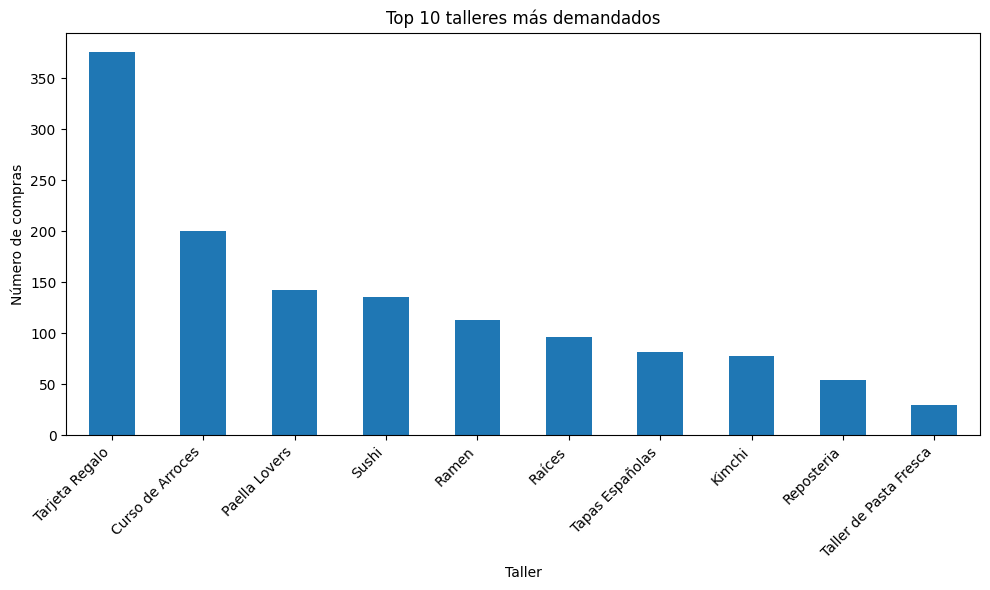

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top10_talleres.plot(kind="bar")

plt.title("Top 10 talleres más demandados")
plt.xlabel("Taller")
plt.ylabel("Número de compras")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 2.4 Facturación por taller

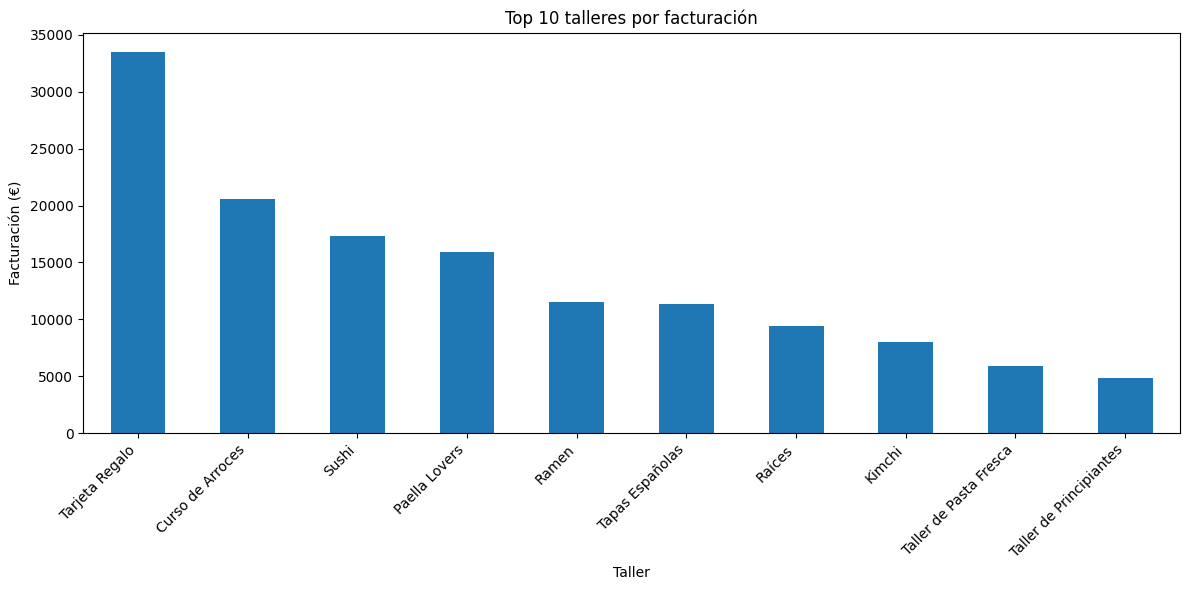

In [165]:
top10_facturacion = (
    df.groupby("Taller")["Importe Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top10_facturacion.plot(kind="bar")

plt.title("Top 10 talleres por facturación")
plt.xlabel("Taller")
plt.ylabel("Facturación (€)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [166]:
print(top10_facturacion)

Taller
Tarjeta Regalo             33500.00
Curso de Arroces           20570.00
Sushi                      17360.00
Paella Lovers              15875.00
Ramen                      11542.00
Tapas Españolas            11392.75
Raíces                      9410.00
Kimchi                      8050.00
Taller de Pasta Fresca      5930.00
Taller de Principiantes     4863.00
Name: Importe Total, dtype: float64


In [167]:
df.groupby("Taller")["Importe Total"].sum()

Taller
Clasicos Valencianos               90.00
Cocas Miquel Ruiz                1915.00
Croquetas                         340.00
Curso Cocina Mexicana            1520.00
Curso de Arroces                20570.00
Esperando selección de curso     1580.00
Kimchi                           8050.00
NOBLE                             190.00
Paella Lovers                   15875.00
Ramen                           11542.00
Raíces                           9410.00
Reposteria                       4150.00
Sushi                           17360.00
Taller de Curry                  1020.00
Taller de Pasta Fresca           5930.00
Taller de Principiantes          4863.00
Tapas Españolas                 11392.75
Tarjeta Regalo                  33500.00
Name: Importe Total, dtype: float64

## 2.5 Métodos de pago

In [168]:
df["Método de Pago"].value_counts()

Método de Pago
Stripe                       414
Visa                         391
Bizum                        219
Tarjeta Regalo (canjeado)    199
Devolución                    48
Google Pay                    39
Datafono                      36
Square                        25
Efectivo                      17
Shopify                       10
Transferência                  6
CANCELADO                      5
Name: count, dtype: int64

In [169]:
metodos_pago = (
    df["Método de Pago"]
    .value_counts(normalize=True) * 100
)

print(round(metodos_pago, 2))

Método de Pago
Stripe                       29.38
Visa                         27.75
Bizum                        15.54
Tarjeta Regalo (canjeado)    14.12
Devolución                    3.41
Google Pay                    2.77
Datafono                      2.56
Square                        1.77
Efectivo                      1.21
Shopify                       0.71
Transferência                 0.43
CANCELADO                     0.35
Name: proportion, dtype: float64


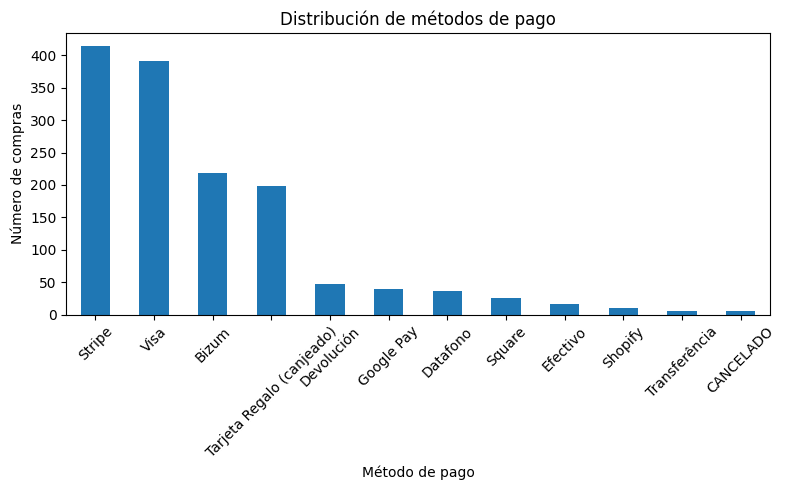

In [170]:
import matplotlib.pyplot as plt

metodos_pago = df["Método de Pago"].value_counts()

plt.figure(figsize=(8,5))

metodos_pago.plot(kind="bar")

plt.title("Distribución de métodos de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de compras")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [171]:
facturacion_pago = (
    df.groupby("Método de Pago")["Importe Total"]
    .sum()
    .sort_values(ascending=False)
)

print(facturacion_pago)

Método de Pago
Stripe                       57994.75
Visa                         46640.00
Bizum                        26107.00
Google Pay                    4070.00
Transferência                 3790.00
Datafono                      3320.00
Square                        3150.00
Efectivo                      1940.00
Tarjeta Regalo (canjeado)     1095.00
Shopify                       1011.00
Devolución                     180.00
CANCELADO                        0.00
Name: Importe Total, dtype: float64


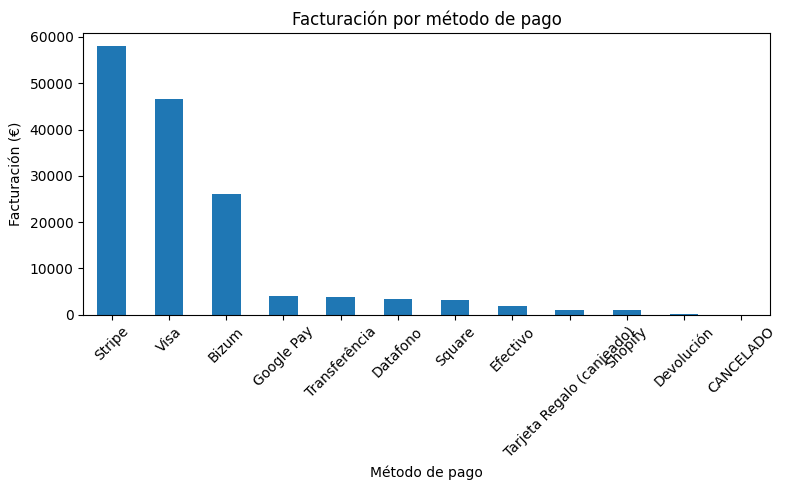

In [172]:
plt.figure(figsize=(8,5))

facturacion_pago.plot(kind="bar")

plt.title("Facturación por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Facturación (€)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [173]:
df["Método de Pago"].value_counts()

Método de Pago
Stripe                       414
Visa                         391
Bizum                        219
Tarjeta Regalo (canjeado)    199
Devolución                    48
Google Pay                    39
Datafono                      36
Square                        25
Efectivo                      17
Shopify                       10
Transferência                  6
CANCELADO                      5
Name: count, dtype: int64

In [174]:
df.groupby("Método de Pago")["Importe Total"].sum()

Método de Pago
Bizum                        26107.00
CANCELADO                        0.00
Datafono                      3320.00
Devolución                     180.00
Efectivo                      1940.00
Google Pay                    4070.00
Shopify                       1011.00
Square                        3150.00
Stripe                       57994.75
Tarjeta Regalo (canjeado)     1095.00
Transferência                 3790.00
Visa                         46640.00
Name: Importe Total, dtype: float64

## 2.6 Análisis temporal

In [175]:
df["Mes"] = df["Fecha de Compra"].dt.to_period("M")

In [176]:
ventas_mes = (
    df.groupby("Mes")["Importe Total"]
    .sum()
)

print(ventas_mes)

Mes
2024-11      150.00
2025-01    14993.00
2025-02     9050.00
2025-03     8500.00
2025-04     8560.00
2025-05    10455.00
2025-06     7570.00
2025-07     6545.00
2025-08     5745.00
2025-09     9943.00
2025-10     5410.00
2025-11     4230.00
2025-12    13120.00
2026-01    14890.00
2026-02    11605.75
2026-03     6960.00
2026-04     6800.00
2026-05     4690.00
2026-06       81.00
Freq: M, Name: Importe Total, dtype: float64


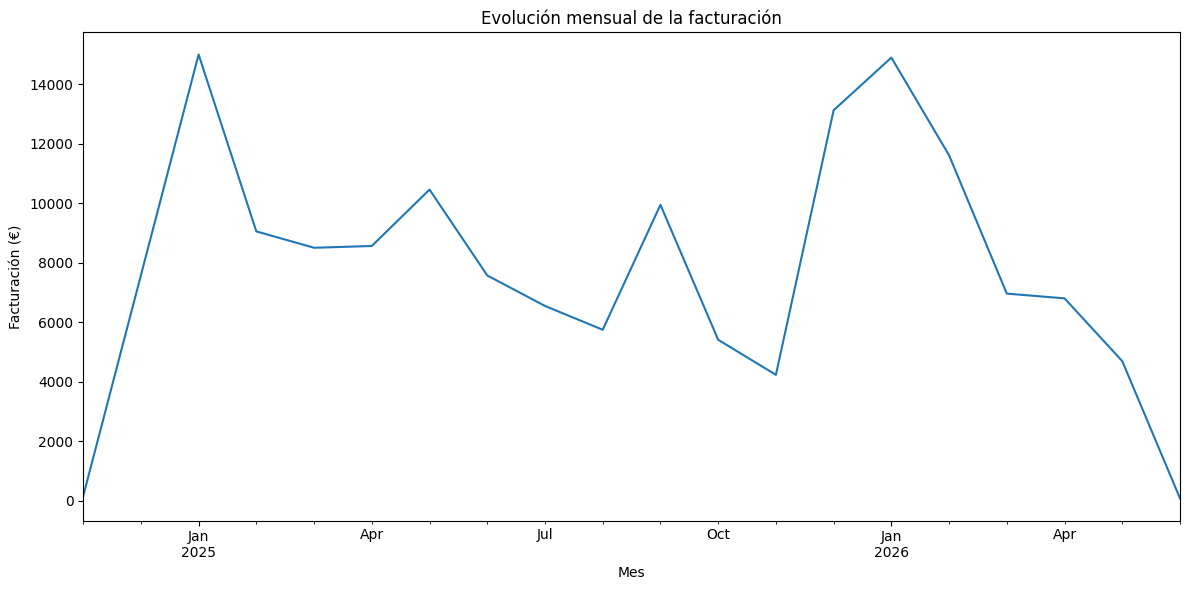

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

ventas_mes.plot()

plt.title("Evolución mensual de la facturación")
plt.xlabel("Mes")
plt.ylabel("Facturación (€)")

plt.tight_layout()
plt.show()

In [178]:
compras_mes = (
    df.groupby("Mes")
    .size()
)

print(compras_mes)

Mes
2024-11      1
2025-01    162
2025-02     92
2025-03     85
2025-04     89
2025-05     92
2025-06     79
2025-07     65
2025-08     52
2025-09     77
2025-10     58
2025-11     45
2025-12    120
2026-01    140
2026-02     78
2026-03     58
2026-04     58
2026-05     56
2026-06      2
Freq: M, dtype: int64


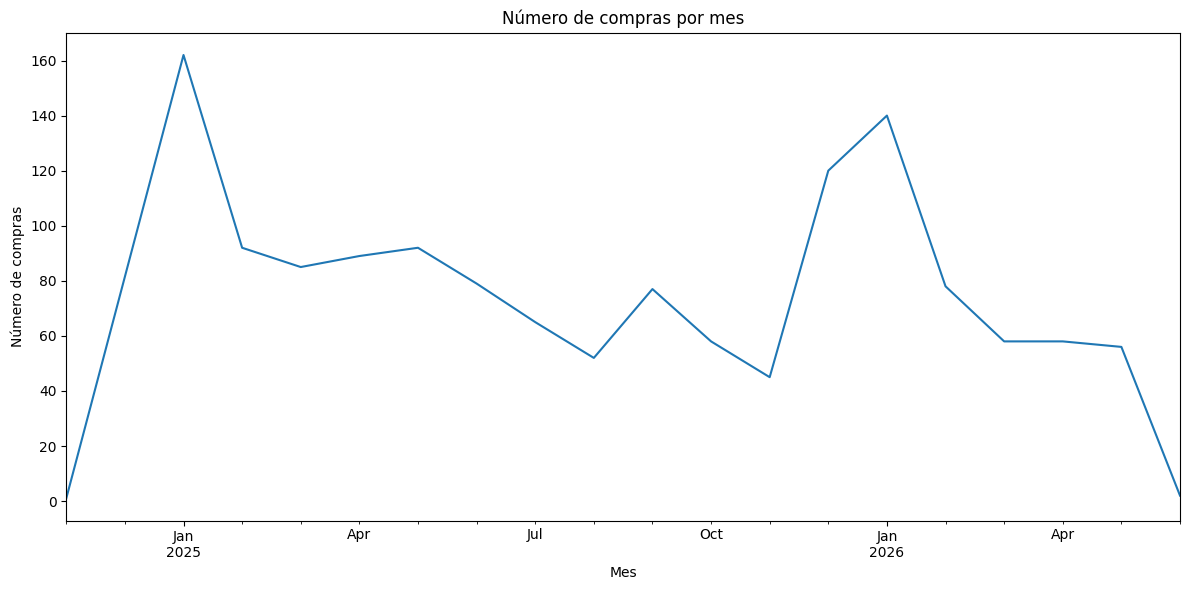

In [179]:
plt.figure(figsize=(12,6))

compras_mes.plot()

plt.title("Número de compras por mes")
plt.xlabel("Mes")
plt.ylabel("Número de compras")

plt.tight_layout()
plt.show()

In [180]:
plazas_mes = (
    df.groupby("Mes")["Cantidad de Plazas"]
    .sum()
)

print(plazas_mes)

Mes
2024-11      0
2025-01    168
2025-02    124
2025-03     76
2025-04     98
2025-05    123
2025-06     86
2025-07     64
2025-08     51
2025-09    114
2025-10     56
2025-11     43
2025-12    102
2026-01    158
2026-02    115
2026-03     80
2026-04     87
2026-05     48
2026-06      2
Freq: M, Name: Cantidad de Plazas, dtype: int64


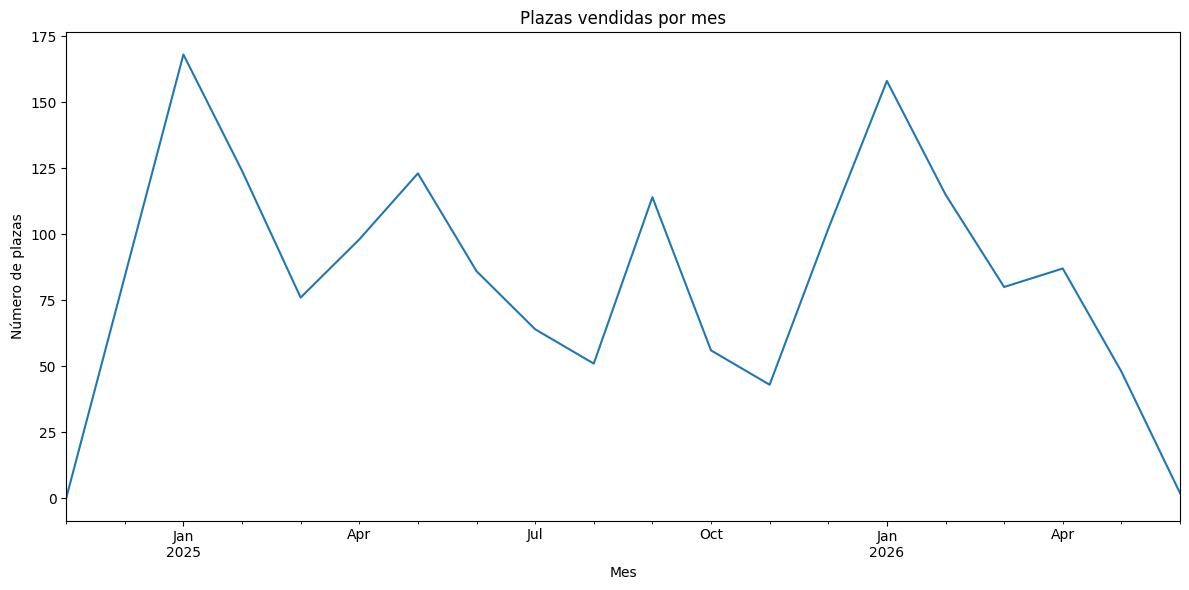

In [181]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plazas_mes.plot()

plt.title("Plazas vendidas por mes")
plt.xlabel("Mes")
plt.ylabel("Número de plazas")

plt.tight_layout()
plt.show()

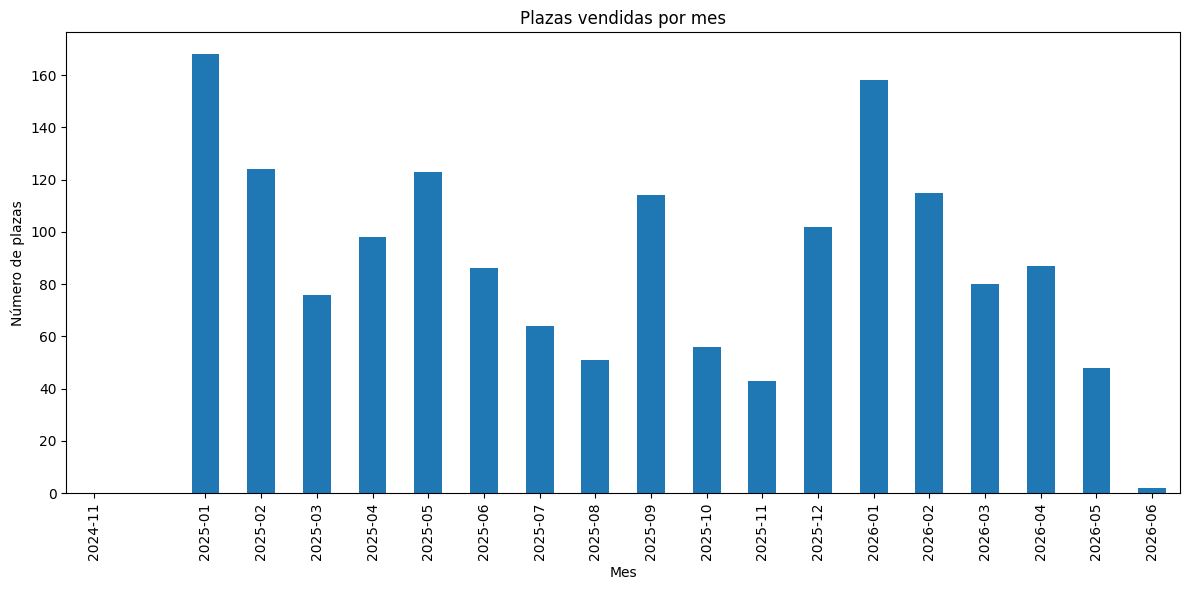

In [182]:
plt.figure(figsize=(12,6))

plazas_mes.plot(kind="bar")

plt.title("Plazas vendidas por mes")
plt.xlabel("Mes")
plt.ylabel("Número de plazas")

plt.tight_layout()
plt.show()

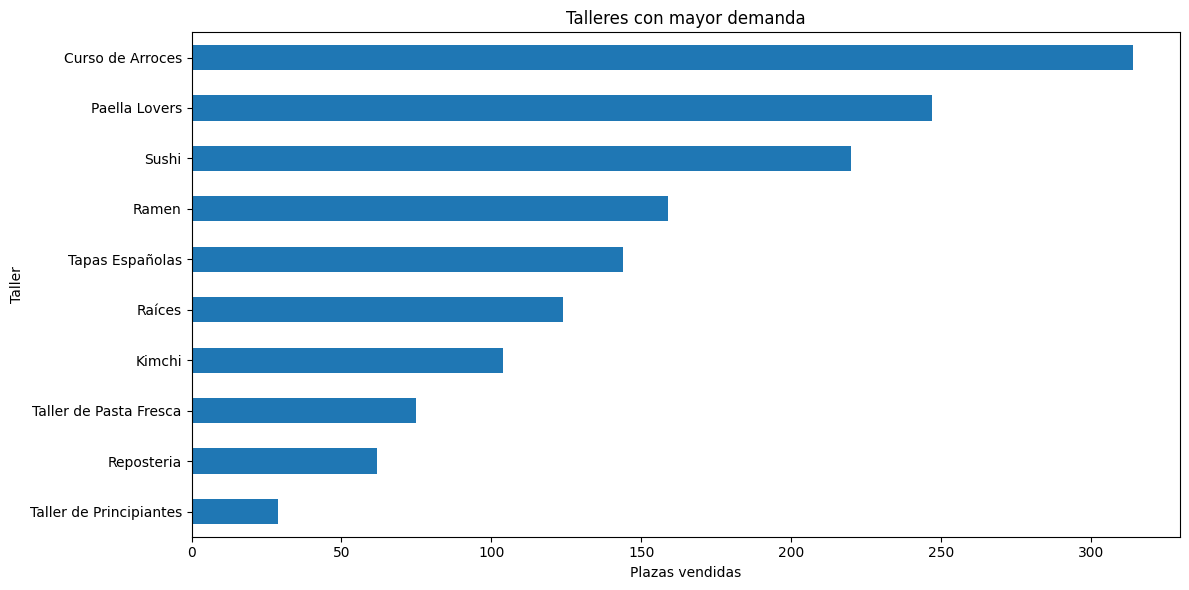

In [271]:
# Top 10 talleres por plazas vendidas

top_talleres = (
    df.groupby("Taller")["Cantidad de Plazas"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_talleres.sort_values().plot(kind="barh")

plt.title("Talleres con mayor demanda")
plt.xlabel("Plazas vendidas")
plt.ylabel("Taller")

plt.tight_layout()
plt.show()

El análisis exploratorio realizado ha permitido obtener una visión detallada del comportamiento de las ventas y de la demanda de los talleres ofrecidos por Food & Fun durante el periodo analizado. A través del estudio de las variables económicas, temporales y operativas, se identificaron patrones relevantes relacionados con la facturación, el volumen de plazas vendidas, la popularidad de los distintos talleres y las preferencias de pago de los clientes.

Los resultados obtenidos muestran diferencias significativas entre los talleres tanto en términos de demanda como de ingresos generados, lo que pone de manifiesto la importancia de analizar conjuntamente indicadores de volumen y rentabilidad. Asimismo, el análisis temporal ha permitido observar la evolución de la actividad comercial a lo largo del periodo estudiado, identificando posibles variaciones estacionales y cambios en los niveles de demanda.

En conjunto, esta fase ha permitido comprender mejor la dinámica del negocio y detectar los principales factores que influyen en el comportamiento de las ventas. Estas conclusiones servirán como base para las siguientes etapas del proyecto, orientadas a la construcción de modelos predictivos capaces de anticipar la demanda y apoyar la toma de decisiones dentro de la empresa.


# 3. Preparación de los datos para Machine Learning


## 3.1 Tratamiento de valores faltantes

In [183]:
df.isnull().sum()

Fecha de Compra          0
Número de Pedido         0
Taller                   0
Fecha Taller           380
Cantidad de Plazas       0
TARJETAS REGALO       1046
Importe Total            0
IMPORTE DEVOLUCIÓN    1397
Método de Pago           0
Unidades Vendidas        0
Mes                      0
dtype: int64

In [184]:
df[["Cantidad de Plazas",
    "TARJETAS REGALO",
    "IMPORTE DEVOLUCIÓN"]] = (
    df[["Cantidad de Plazas",
        "TARJETAS REGALO",
        "IMPORTE DEVOLUCIÓN"]]
    .fillna(0)
)

In [185]:
df.isnull().sum()

Fecha de Compra         0
Número de Pedido        0
Taller                  0
Fecha Taller          380
Cantidad de Plazas      0
TARJETAS REGALO         0
Importe Total           0
IMPORTE DEVOLUCIÓN      0
Método de Pago          0
Unidades Vendidas       0
Mes                     0
dtype: int64

In [186]:
df = df.dropna(
    subset=[
        "Fecha de Compra",
        "Número de Pedido",
        "Taller"
    ]
)

In [187]:
df[df["Importe Total"].isna()]

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago,Unidades Vendidas,Mes


In [188]:
df = df.dropna(subset=["Importe Total"])

In [189]:
df["Método de Pago"] = df["Método de Pago"].fillna("Desconocido")

In [190]:
df["Fecha Taller"] = pd.to_datetime(
    df["Fecha Taller"],
    errors="coerce"
)

In [191]:
df.loc[
    df["Taller"] == "Tarjeta Regalo",
    "Fecha Taller"
] = pd.NaT

In [192]:
df[df["Taller"] == "Tarjeta Regalo"][
    ["Taller", "Fecha Taller"]
].head()

,Taller,Fecha Taller
0,Tarjeta Regalo,NaT
2,Tarjeta Regalo,NaT
3,Tarjeta Regalo,NaT
6,Tarjeta Regalo,NaT
7,Tarjeta Regalo,NaT


In [193]:
df["Fecha Taller"].isna().sum()

np.int64(397)

## 3.2 Selección de variables y definición de la variable objetivo


Una vez completadas las tareas de limpieza y preparación inicial de los datos, se procedió a seleccionar las variables que formarán parte del proceso de modelado. Esta etapa resulta fundamental, ya que permite identificar qué información puede aportar capacidad predictiva y qué variables deben excluirse por no contener información relevante para el aprendizaje del modelo.

La variable **Número de Pedido** fue descartada al tratarse de un identificador único asociado a cada transacción. Aunque resulta útil para la trazabilidad de los registros, no aporta información explicativa sobre el comportamiento de compra de los clientes y podría introducir ruido en el proceso de modelado.

Por otro lado, se mantuvieron las variables relacionadas con las características de la compra y del taller, incluyendo la fecha de compra, la fecha de realización del taller, el nombre del taller, el método de pago, el número de tarjetas regalo adquiridas y el importe total de la transacción.

Como variable objetivo se seleccionó **Cantidad de Plazas**, ya que representa directamente la demanda generada por cada compra. La predicción de esta variable permite estimar el volumen de asistentes esperado para los distintos talleres, proporcionando información de valor para la planificación de recursos, la programación de actividades y la toma de decisiones comerciales dentro de la empresa.


## 3.3 Ingeniería de características

In [194]:
df["Año_Compra"] = df["Fecha de Compra"].dt.year
df["Mes_Compra"] = df["Fecha de Compra"].dt.month
df["Dia_Semana_Compra"] = df["Fecha de Compra"].dt.dayofweek

In [195]:
# Antelación de la compra: cuantos días antes del taller compraron.and

df["Fecha Taller"] = pd.to_datetime(df["Fecha Taller"])

df["Antelacion_Dias"] = (
    df["Fecha Taller"] - df["Fecha de Compra"]
).dt.days

In [196]:
df[
    [
        "Fecha de Compra",
        "Fecha Taller",
        "Antelacion_Dias"
    ]
].head()

,Fecha de Compra,Fecha Taller,Antelacion_Dias
0,2024-11-18,NaT,NaN
1,2025-01-01,2025-03-24,82.0
2,2025-01-01,NaT,NaN
3,2025-01-01,NaT,NaN
4,2025-01-01,2025-03-28,86.0


In [197]:
df["Antelacion_Dias"].describe()

count    1012.000000
mean       43.379447
std        37.379206
min       -35.000000
25%        18.000000
50%        35.000000
75%        59.000000
max       341.000000
Name: Antelacion_Dias, dtype: float64

In [198]:
df[df["Antelacion_Dias"] < 0].shape

(4, 15)

In [199]:
df[df["Antelacion_Dias"] < 0][[
    "Fecha de Compra",
    "Fecha Taller",
    "Taller",
    "Cantidad de Plazas",
    "Importe Total",
    "Antelacion_Dias"
]]

,Fecha de Compra,Fecha Taller,Taller,Cantidad de Plazas,Importe Total,Antelacion_Dias
195,2025-02-08,2025-02-05,Tapas Españolas,2,160.0,-3.0
244,2025-02-25,2025-02-24,Taller de Curry,0,0.0,-1.0
833,2025-10-20,2025-09-15,Taller de Principiantes,2,100.0,-35.0
1206,2026-02-16,2026-02-09,Taller de Principiantes,1,0.0,-7.0


In [200]:
df = df[df["Antelacion_Dias"] >= 0]

Durante el proceso de ingeniería de características se calculó la variable de antelación de compra como la diferencia entre la fecha de realización del taller y la fecha de compra. La revisión de esta variable permitió identificar cuatro registros con valores negativos, lo que implicaba que la compra había sido registrada con posterioridad a la fecha del taller.

Dado que estos casos representaban menos del 0,3% del conjunto de datos y se consideraron inconsistencias puntuales respecto a la lógica temporal del proceso de compra, dichos registros fueron excluidos del análisis para evitar distorsiones en el entrenamiento de los modelos predictivos.


In [201]:
df["Antelacion_Dias"].describe()

count    1008.000000
mean       43.597222
std        37.282630
min         0.000000
25%        18.000000
50%        35.000000
75%        59.000000
max       341.000000
Name: Antelacion_Dias, dtype: float64

Con el objetivo de mejorar la capacidad predictiva de los modelos, se llevó a cabo un proceso de ingeniería de características mediante la generación de nuevas variables derivadas de la información temporal disponible en el conjunto de datos.

A partir de la fecha de compra se extrajeron variables relacionadas con el año, el mes y el día de la semana en el que se realizó cada transacción. Estas variables permiten capturar posibles patrones estacionales y diferencias en el comportamiento de compra a lo largo del tiempo.

Asimismo, se calculó la variable *Antelación de Compra*, definida como el número de días transcurridos entre la fecha de compra y la fecha de celebración del taller. Esta característica resulta especialmente relevante desde el punto de vista del negocio, ya que permite analizar la planificación de las reservas y estudiar si la anticipación de la compra influye en la demanda de los talleres.


## 3.4 Codificación de variables categóricas

In [202]:
df.select_dtypes(include=["object"]).columns

/var/folders/fd/qpyzc0v159bblqkhjd540pr80000gn/T/ipykernel_1278/2790643224.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object"]).columns


Index(['Número de Pedido', 'Taller', 'Método de Pago'], dtype='str')

In [203]:
df["Método de Pago"].value_counts()

Método de Pago
Visa                         279
Stripe                       260
Tarjeta Regalo (canjeado)    192
Bizum                        144
Devolución                    33
Datafono                      29
Google Pay                    26
Square                        18
Efectivo                      15
Transferência                  6
Shopify                        5
CANCELADO                      1
Name: count, dtype: int64

In [204]:
df["Taller"].nunique()

17

In [205]:
y = df["Cantidad de Plazas"]

In [206]:
X = df.drop(
    columns=[
        "Cantidad de Plazas",
        "Número de Pedido"
    ]
)

In [207]:
X.info()

<class 'pandas.DataFrame'>
Index: 1008 entries, 1 to 1407
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha de Compra     1008 non-null   datetime64[us]
 1   Taller              1008 non-null   str           
 2   Fecha Taller        1008 non-null   datetime64[us]
 3   TARJETAS REGALO     1008 non-null   float64       
 4   Importe Total       1008 non-null   float64       
 5   IMPORTE DEVOLUCIÓN  1008 non-null   float64       
 6   Método de Pago      1008 non-null   str           
 7   Unidades Vendidas   1008 non-null   float64       
 8   Mes                 1008 non-null   period[M]     
 9   Año_Compra          1008 non-null   int32         
 10  Mes_Compra          1008 non-null   int32         
 11  Dia_Semana_Compra   1008 non-null   int32         
 12  Antelacion_Dias     1008 non-null   float64       
dtypes: datetime64[us](2), float64(5), int32(3), period[M](1), str(2)

In [208]:
print(df.shape)

(1008, 15)


In [209]:
df.head()

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago,Unidades Vendidas,Mes,Año_Compra,Mes_Compra,Dia_Semana_Compra,Antelacion_Dias
1,2025-01-01,43861545,Kimchi,2025-03-24,2,0.0,180.0,0.0,Bizum,2.0,2025-01,2025,1,2,82.0
4,2025-01-01,43861549,Ramen,2025-03-28,2,0.0,162.0,0.0,Visa,2.0,2025-01,2025,1,2,86.0
5,2025-01-02,43861618,Ramen,2025-02-07,1,0.0,90.0,0.0,Visa,1.0,2025-01,2025,1,3,36.0
10,2025-01-02,43861606,Raíces,2025-03-29,1,0.0,90.0,0.0,Bizum,1.0,2025-01,2025,1,3,86.0
13,2025-01-02,43861611,Taller de Pasta Fresca,2025-02-14,2,0.0,180.0,0.0,Visa,2.0,2025-01,2025,1,3,43.0


Tras el tratamiento inicial de valores faltantes, se excluyeron las compras correspondientes a tarjetas regalo, ya que no estaban asociadas a un taller específico ni disponían de fecha de realización. Estas operaciones representaban una compra de saldo para consumo futuro y no una reserva efectiva de plazas, por lo que no resultaban adecuadas para el modelado de la demanda de talleres. Asimismo, se eliminaron cuatro registros con valores negativos en la variable de antelación de compra al considerarse inconsistencias temporales.

In [210]:
print(df["Taller"].value_counts())

Taller
Curso de Arroces                200
Paella Lovers                   142
Sushi                           136
Ramen                           113
Raíces                           95
Tapas Españolas                  80
Kimchi                           77
Reposteria                       53
Taller de Pasta Fresca           30
Taller de Principiantes          26
Cocas Miquel Ruiz                16
Curso Cocina Mexicana            12
Taller de Curry                  10
Esperando selección de curso      6
NOBLE                             4
Clasicos Valencianos              4
Croquetas                         4
Name: count, dtype: int64


## 3.5 División de los datos en entrenamiento y prueba

Una vez finalizadas las tareas de limpieza, transformación y preparación de los datos, el conjunto final fue dividido en dos subconjuntos: entrenamiento y prueba. Esta separación permite evaluar la capacidad de generalización de los modelos de Machine Learning sobre datos no utilizados durante el proceso de aprendizaje.

Se empleó una partición del 80% de los registros para entrenamiento y un 20% para prueba, siguiendo una práctica habitual en problemas de predicción supervisada. Además, se fijó una semilla aleatoria (random_state=42) para garantizar la reproducibilidad de los resultados obtenidos.

In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [212]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (806, 13)
X_test : (202, 13)
y_train: (806,)
y_test : (202,)


Tras la partición del conjunto de datos, se obtuvieron 806 observaciones para entrenamiento y 202 observaciones para prueba. Esta distribución proporciona una cantidad suficiente de ejemplos para el aprendizaje de los modelos, manteniendo al mismo tiempo un conjunto independiente que permite evaluar objetivamente su rendimiento predictivo.

# 4. Desarrollo de modelos predictivos

Una vez completadas las fases de integración, análisis exploratorio y preparación de los datos, se procedió al desarrollo de modelos predictivos orientados a estimar la demanda de plazas en los talleres gastronómicos.

El objetivo principal consiste en predecir la variable Cantidad de Plazas, utilizando la información histórica disponible sobre los talleres, el comportamiento temporal de las compras y las características económicas de las transacciones.

Para ello se implementaron distintos algoritmos de Machine Learning supervisado y posteriormente se comparó su rendimiento mediante métricas de evaluación adecuadas para problemas de regresión.

## 4.1 Regresión Lineal
Como punto de partida se utilizó un modelo de Regresión Lineal Múltiple. Este algoritmo permite establecer una relación lineal entre las variables explicativas y la variable objetivo, proporcionando además una elevada interpretabilidad de los resultados obtenidos.

Aunque se trata de un modelo relativamente sencillo, constituye una referencia útil para comparar posteriormente el rendimiento de algoritmos más avanzados.

In [213]:
X.dtypes

Fecha de Compra       datetime64[us]
Taller                           str
Fecha Taller          datetime64[us]
TARJETAS REGALO              float64
Importe Total                float64
IMPORTE DEVOLUCIÓN           float64
Método de Pago                   str
Unidades Vendidas            float64
Mes                        period[M]
Año_Compra                     int32
Mes_Compra                     int32
Dia_Semana_Compra              int32
Antelacion_Dias              float64
dtype: object

In [214]:
X = X.drop(
    columns=[
        "Fecha de Compra",
        "Fecha Taller",
        "Mes"
    ]
)

In [215]:
X = pd.get_dummies(
    X,
    columns=[
        "Taller",
        "Método de Pago"
    ],
    drop_first=True
)

In [216]:
X.info()

<class 'pandas.DataFrame'>
Index: 1008 entries, 1 to 1407
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   TARJETAS REGALO                           1008 non-null   float64
 1   Importe Total                             1008 non-null   float64
 2   IMPORTE DEVOLUCIÓN                        1008 non-null   float64
 3   Unidades Vendidas                         1008 non-null   float64
 4   Año_Compra                                1008 non-null   int32  
 5   Mes_Compra                                1008 non-null   int32  
 6   Dia_Semana_Compra                         1008 non-null   int32  
 7   Antelacion_Dias                           1008 non-null   float64
 8   Taller_Cocas Miquel Ruiz                  1008 non-null   bool   
 9   Taller_Croquetas                          1008 non-null   bool   
 10  Taller_Curso Cocina Mexicana              1008 non-n

In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [218]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [219]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

y_pred_lr = modelo_lr.predict(X_test)

print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr) ** 0.5)

R²: 1.0
MAE: 1.795040267047331e-14
RMSE: 2.0656519182079758e-14


fuga de información (data leakage)
El modelo está intentando predecir:
Cantidad de Plazas

pero le estás dando como entrada:
Unidades Vendidas

que es exactamente la misma información con otro nombre.

Durante la fase de modelado se detectó que la variable Unidades Vendidas coincidía exactamente con la variable objetivo (Cantidad de Plazas), por lo que fue excluida del conjunto de variables predictoras para evitar problemas de fuga de información y garantizar una evaluación realista del rendimiento de los modelos.

In [220]:
X = X.drop(columns=["Unidades Vendidas"])

In [221]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [222]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

In [223]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr)**0.5)

R²: 0.8070734193665772
MAE: 0.3384496904291844
RMSE: 0.5136618707292976


Como primer modelo predictivo se implementó una Regresión Lineal Múltiple con el objetivo de estimar la cantidad de plazas vendidas en los talleres gastronómicos. Este modelo fue utilizado como referencia inicial debido a su simplicidad e interpretabilidad.

Los resultados obtenidos muestran un coeficiente de determinación (R²) de 0,807, lo que indica que el modelo es capaz de explicar aproximadamente el 80,7% de la variabilidad observada en la demanda de plazas. Asimismo, se obtuvo un error absoluto medio (MAE) de 0,338 plazas y una raíz del error cuadrático medio (RMSE) de 0,514 plazas.

Estos resultados sugieren que existe una relación significativa entre las variables seleccionadas y la demanda de los talleres, permitiendo obtener predicciones con un nivel de precisión elevado. Por tanto, la regresión lineal constituye una base sólida para el desarrollo de modelos más avanzados y para la comparación posterior de diferentes algoritmos de aprendizaje automático.

## 4.2 Random Forest

Con el objetivo de mejorar la capacidad predictiva obtenida mediante la regresión lineal, se implementó un modelo Random Forest Regressor. Este algoritmo pertenece a la familia de los métodos de ensamble y combina múltiples árboles de decisión para generar una predicción final más robusta y precisa.

Una de las principales ventajas de Random Forest es su capacidad para capturar relaciones no lineales entre las variables, así como interacciones complejas que los modelos lineales no pueden representar adecuadamente. Por este motivo, constituye una alternativa especialmente adecuada para problemas de predicción de demanda.


In [224]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [225]:
y_pred_rf = modelo_rf.predict(X_test)

In [226]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf) ** 0.5)

R²: 0.8500395866694144
MAE: 0.1721113861386139
RMSE: 0.45286588921430304


In [227]:
import pandas as pd

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias.head(10))

Importe Total                     0.805724
Antelacion_Dias                   0.056943
Método de Pago_Devolución         0.029209
Mes_Compra                        0.020350
Taller_Taller de Principiantes    0.016117
Dia_Semana_Compra                 0.014404
Año_Compra                        0.012513
Taller_Tapas Españolas            0.008231
Taller_Paella Lovers              0.007846
Taller_Curso de Arroces           0.004920
dtype: float64


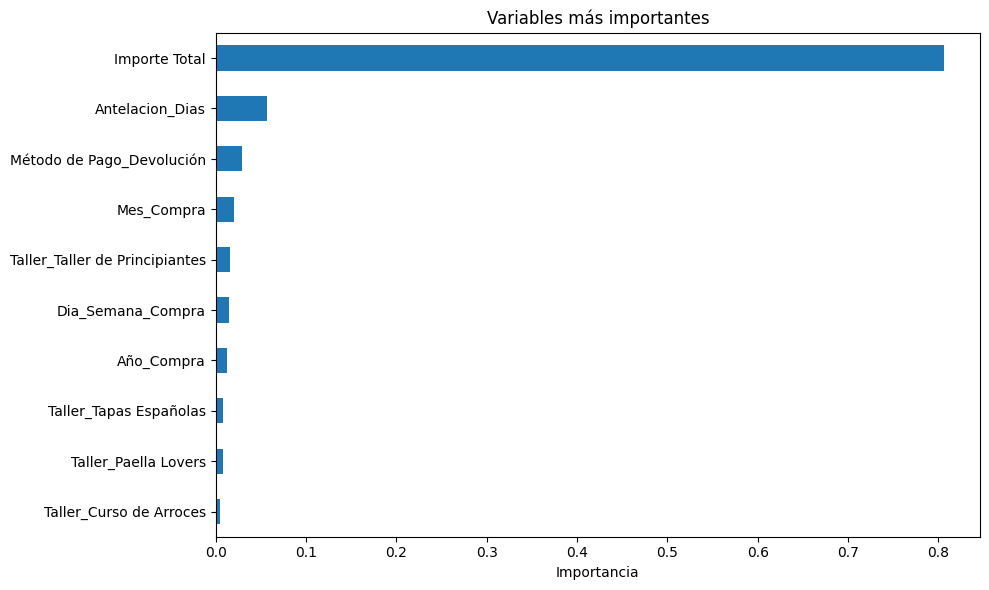

In [228]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

importancias.head(10).sort_values().plot(kind="barh")

plt.title("Variables más importantes")
plt.xlabel("Importancia")

plt.tight_layout()
plt.show()

Con el objetivo de mejorar los resultados obtenidos mediante la regresión lineal, se implementó un modelo Random Forest Regressor. Este algoritmo construye múltiples árboles de decisión sobre diferentes subconjuntos de los datos y combina sus predicciones, lo que permite capturar relaciones complejas y patrones no lineales presentes en la información.

Los resultados obtenidos muestran una mejora respecto al modelo de regresión lineal. El coeficiente de determinación alcanzó un valor de R² = 0,850, indicando que el modelo es capaz de explicar aproximadamente el 85% de la variabilidad observada en la demanda de plazas. Asimismo, el error absoluto medio (MAE) se redujo hasta 0,172 plazas y la raíz del error cuadrático medio (RMSE) alcanzó un valor de 0,453 plazas.

Estos resultados sugieren que Random Forest representa con mayor precisión el comportamiento de la demanda, logrando predicciones más ajustadas que las obtenidas mediante la regresión lineal. La capacidad del algoritmo para modelar relaciones no lineales entre las variables explica gran parte de esta mejora en el rendimiento.

## 4.3 XGBoost 


In [229]:
import xgboost
print(xgboost.__version__)

3.2.0


In [230]:
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

modelo_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [231]:
y_pred_xgb = modelo_xgb.predict(X_test)

In [232]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R²:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y_test, y_pred_xgb)**0.5)

R²: 0.8472974896430969
MAE: 0.19405913352966309
RMSE: 0.4569875582163731


Con el objetivo de evaluar un algoritmo más avanzado, se implementó un modelo basado en XGBoost (Extreme Gradient Boosting), una de las técnicas de aprendizaje automático más utilizadas en problemas de predicción debido a su elevada capacidad para capturar patrones complejos y relaciones no lineales entre las variables.

XGBoost se basa en la construcción secuencial de árboles de decisión, donde cada nuevo árbol corrige los errores cometidos por los anteriores. Esta estrategia permite generar modelos altamente precisos y robustos, especialmente en conjuntos de datos con múltiples variables explicativas.

Tras el entrenamiento y evaluación del modelo, se obtuvo un coeficiente de determinación (R²) de 0,847, lo que indica que el algoritmo es capaz de explicar aproximadamente el 84,7% de la variabilidad observada en la demanda de plazas. Asimismo, se registró un error absoluto medio (MAE) de 0,194 plazas y una raíz del error cuadrático medio (RMSE) de 0,457 plazas.

Los resultados obtenidos muestran un rendimiento muy competitivo y superior al alcanzado por la regresión lineal. Sin embargo, aunque las diferencias son reducidas, XGBoost no logró superar el desempeño obtenido por el modelo Random Forest, que presentó una mayor capacidad explicativa y menores errores de predicción.

Por tanto, aunque XGBoost constituye una alternativa sólida para la estimación de la demanda de talleres, los resultados obtenidos en este estudio justifican la selección de Random Forest como modelo final.

## 4.4 Comparación de modelos

Con el fin de identificar el modelo más adecuado para la predicción de la demanda de plazas, se compararon los resultados obtenidos mediante Regresión Lineal, Random Forest y XGBoost. La evaluación se realizó utilizando las métricas R², MAE y RMSE, ampliamente empleadas en problemas de regresión.

| Modelo           | R²    | MAE   | RMSE  |
| ---------------- | ----- | ----- | ----- |
| Regresión Lineal | 0,807 | 0,338 | 0,514 |
| Random Forest    | 0,850 | 0,172 | 0,453 |
| XGBoost          | 0,847 | 0,194 | 0,457 |

Los resultados muestran que los tres modelos presentan una capacidad predictiva elevada, alcanzando valores de R² superiores al 80%. No obstante, existen diferencias relevantes en cuanto a precisión y capacidad explicativa.

La Regresión Lineal obtuvo un R² de 0,807, demostrando que las variables seleccionadas poseen una relación significativa con la demanda de plazas. Sin embargo, su naturaleza lineal limita su capacidad para capturar patrones más complejos presentes en los datos.

Por su parte, XGBoost mejoró notablemente los resultados de la regresión lineal, alcanzando un R² de 0,847 y reduciendo considerablemente los errores de predicción. Estos resultados confirman la capacidad de los modelos de boosting para representar relaciones no lineales y patrones complejos.

Sin embargo, el mejor rendimiento global fue obtenido por Random Forest, que alcanzó un R² de 0,850 y presentó simultáneamente los valores más bajos de MAE y RMSE. Esto indica que el modelo no solo explica una mayor proporción de la variabilidad observada en la demanda, sino que además genera predicciones más precisas y consistentes.

A partir de estos resultados, se seleccionó Random Forest como modelo final para la predicción de la demanda de plazas en los talleres gastronómicos. Su equilibrio entre capacidad explicativa, precisión predictiva e interpretabilidad lo convierte en la alternativa más adecuada para los objetivos planteados en este trabajo.


## 4.5 Selección del modelo final

In [233]:
import pandas as pd

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias.head(10)

Importe Total                     0.805724
Antelacion_Dias                   0.056943
Método de Pago_Devolución         0.029209
Mes_Compra                        0.020350
Taller_Taller de Principiantes    0.016117
Dia_Semana_Compra                 0.014404
Año_Compra                        0.012513
Taller_Tapas Españolas            0.008231
Taller_Paella Lovers              0.007846
Taller_Curso de Arroces           0.004920
dtype: float64

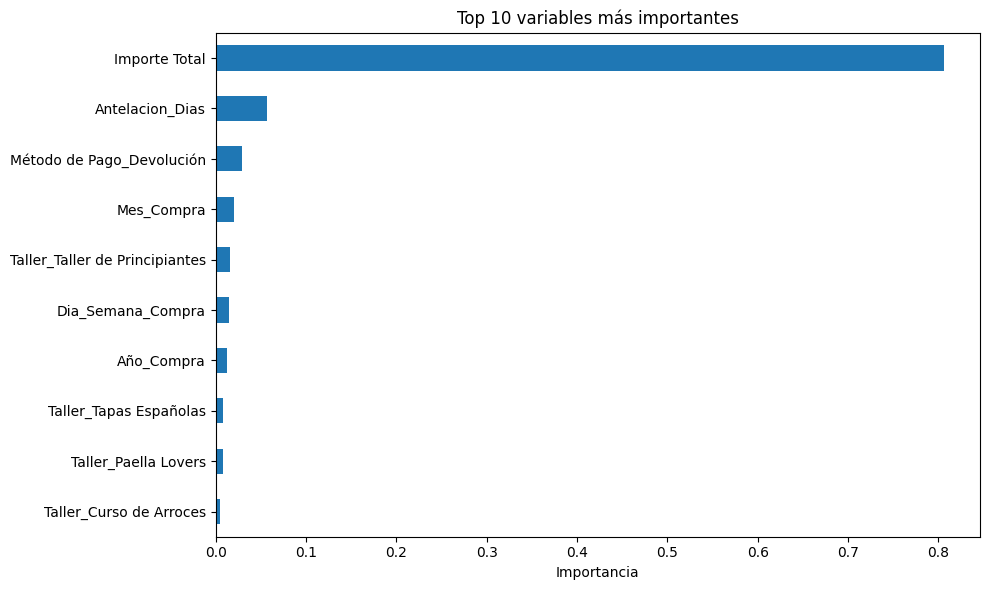

In [234]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

importancias.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")

plt.tight_layout()
plt.show()

In [235]:
importancias.head(10)

Importe Total                     0.805724
Antelacion_Dias                   0.056943
Método de Pago_Devolución         0.029209
Mes_Compra                        0.020350
Taller_Taller de Principiantes    0.016117
Dia_Semana_Compra                 0.014404
Año_Compra                        0.012513
Taller_Tapas Españolas            0.008231
Taller_Paella Lovers              0.007846
Taller_Curso de Arroces           0.004920
dtype: float64

Una vez identificado Random Forest como el modelo con mejor rendimiento, se analizó la importancia relativa de las variables utilizadas en la predicción de la demanda de plazas.

Los resultados muestran que la variable con mayor influencia es el **Importe Total** de la compra, concentrando aproximadamente el 80,6% de la importancia total del modelo. Este resultado es coherente desde el punto de vista del negocio, ya que existe una relación directa entre el número de plazas adquiridas y el importe abonado por el cliente.

La segunda variable más relevante es la **Antelación de Compra**, lo que sugiere que el tiempo transcurrido entre la compra y la celebración del taller influye en el comportamiento de la demanda. Este hallazgo indica que la planificación de las reservas constituye un factor relevante para comprender las dinámicas de venta de los talleres.

Asimismo, variables temporales como el **Mes de Compra**, el **Día de la Semana** y el **Año de Compra** también presentan capacidad explicativa, aunque con una influencia menor. Esto sugiere la existencia de patrones estacionales y comportamientos de compra asociados a determinados periodos del año.

Por otro lado, algunos talleres específicos, como *Taller de Principiantes*, *Tapas Españolas*, *Paella Lovers* y *Curso de Arroces*, aparecen entre las variables más influyentes, indicando que el tipo de actividad ofertada tiene un impacto significativo sobre la demanda.

En conjunto, los resultados ponen de manifiesto que la demanda de plazas está condicionada tanto por factores económicos como por variables temporales y características propias de los talleres. Esta información puede resultar de utilidad para la planificación de la oferta formativa y la optimización de las estrategias comerciales de la empresa.


## 4.6 Evaluación del impacto de la variable Importe Total

In [236]:
# Crear una versión sin Importe Total

X_sin_importe = X.drop(columns=["Importe Total"])

# División entrenamiento-prueba

from sklearn.model_selection import train_test_split

X_train_si, X_test_si, y_train_si, y_test_si = train_test_split(
    X_sin_importe,
    y,
    test_size=0.20,
    random_state=42
)

# Random Forest

from sklearn.ensemble import RandomForestRegressor

modelo_rf_si = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_si.fit(X_train_si, y_train_si)

# Predicciones

y_pred_si = modelo_rf_si.predict(X_test_si)

# Métricas

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("R²:", r2_score(y_test_si, y_pred_si))
print("MAE:", mean_absolute_error(y_test_si, y_pred_si))
print("RMSE:", mean_squared_error(y_test_si, y_pred_si)**0.5)

R²: 0.41588695581023116
MAE: 0.5610303708942324
RMSE: 0.8937781801429391


A pesar de la pérdida de capacidad predictiva, el modelo continúa siendo capaz de explicar aproximadamente el 41,6% de la variabilidad observada en la demanda utilizando exclusivamente variables temporales, características de los talleres y datos operativos de las transacciones.

Este resultado confirma que la demanda no depende únicamente del importe económico asociado a la compra, sino también de factores relacionados con el comportamiento de los clientes y la planificación de las reservas.

Por tanto, aunque la inclusión de la variable *Importe Total* mejora notablemente el rendimiento predictivo, las restantes variables conservan capacidad explicativa suficiente para identificar patrones de demanda relevantes desde el punto de vista empresarial.


# 5. Evaluación de los modelos sin la variable Importe Total

## 5.1 Redefinición de variables predictoras (X) y variable objetivo (y)

Con el objetivo de evaluar la influencia de la variable Importe Total sobre la capacidad predictiva de los modelos, se construyó un nuevo conjunto de variables predictoras excluyendo dicha variable. De esta forma, se pretende analizar el rendimiento de los modelos utilizando únicamente información disponible antes de la celebración del taller.

In [237]:
df.columns

Index(['Fecha de Compra', 'Número de Pedido', 'Taller', 'Fecha Taller',
       'Cantidad de Plazas', 'TARJETAS REGALO', 'Importe Total',
       'IMPORTE DEVOLUCIÓN', 'Método de Pago', 'Unidades Vendidas', 'Mes',
       'Año_Compra', 'Mes_Compra', 'Dia_Semana_Compra', 'Antelacion_Dias'],
      dtype='str')

In [238]:
# Variables predictoras

X = df[
    [
        "Taller",
        "Mes_Compra",
        "Dia_Semana_Compra",
        "Antelacion_Dias",
        "Método de Pago"
    ]
]

# Variable objetivo

y = df["Cantidad de Plazas"]

In [239]:
X = pd.get_dummies(
    X,
    columns=["Taller", "Método de Pago"],
    drop_first=True
)

In [240]:
X.head()

,Mes_Compra,Dia_Semana_Compra,Antelacion_Dias,Taller_Cocas Miquel Ruiz,Taller_Croquetas,Taller_Curso Cocina Mexicana,Taller_Curso de Arroces,Taller_Esperando selección de curso,Taller_Kimchi,Taller_NOBLE,...,Método de Pago_Datafono,Método de Pago_Devolución,Método de Pago_Efectivo,Método de Pago_Google Pay,Método de Pago_Shopify,Método de Pago_Square,Método de Pago_Stripe,Método de Pago_Tarjeta Regalo (canjeado),Método de Pago_Transferência,Método de Pago_Visa
1,1,2,82.0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,2,86.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,1,3,36.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10,1,3,86.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13,1,3,43.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [241]:
X.dtypes

Mes_Compra                                    int32
Dia_Semana_Compra                             int32
Antelacion_Dias                             float64
Taller_Cocas Miquel Ruiz                       bool
Taller_Croquetas                               bool
Taller_Curso Cocina Mexicana                   bool
Taller_Curso de Arroces                        bool
Taller_Esperando selección de curso            bool
Taller_Kimchi                                  bool
Taller_NOBLE                                   bool
Taller_Paella Lovers                           bool
Taller_Ramen                                   bool
Taller_Raíces                                  bool
Taller_Reposteria                              bool
Taller_Sushi                                   bool
Taller_Taller de Curry                         bool
Taller_Taller de Pasta Fresca                  bool
Taller_Taller de Principiantes                 bool
Taller_Tapas Españolas                         bool
Método de Pa

In [242]:
# División entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [243]:
# Regresión lineal
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train,
    y_train
)

pred_lr = modelo_lr.predict(
    X_test
)

In [244]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

print("R² =", r2_score(y_test, pred_lr))
print("MAE =", mean_absolute_error(y_test, pred_lr))
print("RMSE =", np.sqrt(mean_squared_error(y_test, pred_lr)))

R² = 0.4823053972492207
MAE = 0.5297868066864078
RMSE = 0.841430236534338


# 6. Evaluación de los modelos sin la variable Taller


## 6.1 Redefinición de variables predictoras (X) y variable objetivo (y)


Con el objetivo de analizar la influencia de la variable Taller sobre la capacidad predictiva de los modelos, se construyó un nuevo conjunto de variables predictoras excluyendo dicha información. De este modo, se pretende evaluar hasta qué punto la ocupación puede explicarse únicamente mediante variables temporales y características asociadas al proceso de compra.

In [245]:
# Variables predictoras sin la variable Taller

X = df[
    [
        "Mes_Compra",
        "Dia_Semana_Compra",
        "Antelacion_Dias",
        "Método de Pago"
    ]
]

# Variable objetivo

y = df["Cantidad de Plazas"]

In [246]:
# One-Hot Encoding de la variable Método de Pago
# Cambiamos las variables categoricas 


X = pd.get_dummies(
    X,
    columns=["Método de Pago"],
    drop_first=True
)

In [247]:
#División entrenamiento/prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [248]:
#Modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train,
    y_train
)

pred_lr = modelo_lr.predict(
    X_test
)


In [249]:
# Evaluación
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2_lr = r2_score(y_test, pred_lr)

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lr
    )
)

print("R² =", r2_lr)
print("MAE =", mae_lr)
print("RMSE =", rmse_lr)

R² = 0.4462216935171266
MAE = 0.5795625015158227
RMSE = 0.8702604861577534


In [250]:
#Modelo Random Forest
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

modelo_rf.fit(
    X_train,
    y_train
)

pred_rf = modelo_rf.predict(
    X_test
)

In [251]:
#Evaluación
r2_rf = r2_score(y_test, pred_rf)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        pred_rf
    )
)

print("R² =", r2_rf)
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)

R² = 0.16984938284219475
MAE = 0.6906566674524595
RMSE = 1.06551542976275


In [252]:
# Modelo XGBoost
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

modelo_xgb.fit(
    X_train,
    y_train
)

pred_xgb = modelo_xgb.predict(
    X_test
)

In [253]:
#Evaluación
r2_xgb = r2_score(y_test, pred_xgb)

mae_xgb = mean_absolute_error(
    y_test,
    pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        pred_xgb
    )
)

print("R² =", r2_xgb)
print("MAE =", mae_xgb)
print("RMSE =", rmse_xgb)

R² = -0.19626569747924805
MAE = 0.7208536267280579
RMSE = 1.2790724229835462


In [254]:
#Comparación de modelos
resultados_sin_taller = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],
    "R²": [
        r2_lr,
        r2_rf,
        r2_xgb
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ]
})

resultados_sin_taller

,Modelo,R²,MAE,RMSE
0,Regresión Lineal,0.446222,0.579563,0.870260
1,Random Forest,0.169849,0.690657,1.065515
2,XGBoost,-0.196266,0.720854,1.279072


La eliminación de la variable Taller produjo una reducción limitada en el rendimiento de la Regresión Lineal, pasando de un coeficiente de determinación R² cercano a 0,48 a un valor de 0,45. Este resultado indica que, aunque el tipo de taller aporta información relevante, una parte importante de la capacidad predictiva ya se encuentra recogida en variables relacionadas con el comportamiento de compra de los clientes, especialmente la antelación de la reserva y las variables temporales.

Por otro lado, los modelos Random Forest y XGBoost mostraron un rendimiento inferior, lo que sugiere que las relaciones presentes en los datos son predominantemente lineales y pueden ser capturadas adecuadamente mediante un modelo de Regresión Lineal.


# 7. Análisis de los factores que influyen en la ocupación

## 7.1 Ocupación por mes

In [255]:
# Analizar la ocupación total registrada en cada mes

ocupacion_mes = (
    df.groupby("Mes_Compra")["Cantidad de Plazas"]
    .sum()
)

ocupacion_mes

Mes_Compra
1     324
2     234
3     148
4     175
5     171
6      86
7      64
8      48
9     114
10     53
11     41
12    100
Name: Cantidad de Plazas, dtype: int64

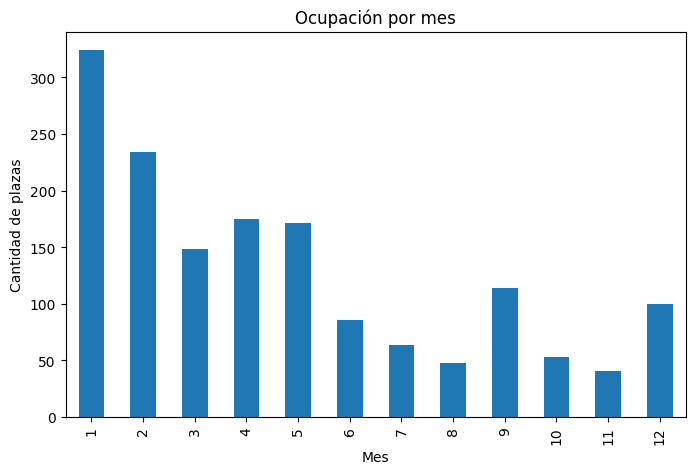

In [256]:
# Representar gráficamente la ocupación por mes

ocupacion_mes.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ocupación por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de plazas")

plt.show()

## 7.2 Antelación de compra


In [257]:
# Analizar con cuántos días de antelación realizan las reservas los clientes

df["Antelacion_Dias"].describe()

count    1008.000000
mean       43.597222
std        37.282630
min         0.000000
25%        18.000000
50%        35.000000
75%        59.000000
max       341.000000
Name: Antelacion_Dias, dtype: float64

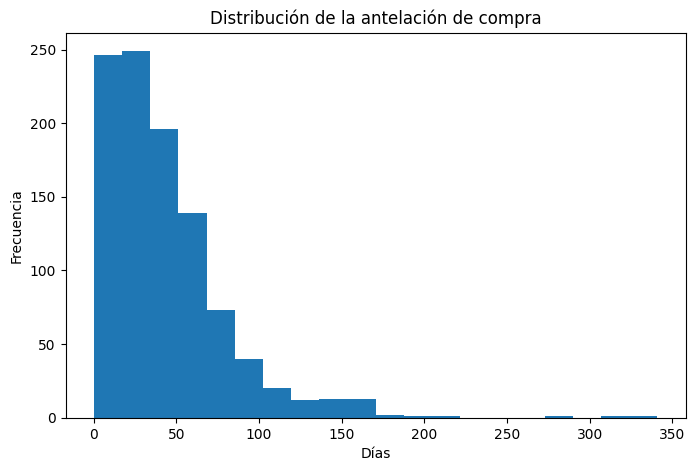

In [258]:
# Visualizar la distribución de la antelación de compra

plt.figure(figsize=(8,5))

plt.hist(
    df["Antelacion_Dias"],
    bins=20
)

plt.title("Distribución de la antelación de compra")
plt.xlabel("Días")
plt.ylabel("Frecuencia")

plt.show()

## 7.3 Compras por día de la semana

In [259]:
# Analizar qué días de la semana se realizan más reservas

compras_dia = (
    df.groupby("Dia_Semana_Compra")["Cantidad de Plazas"]
    .sum()
)

compras_dia

Dia_Semana_Compra
0    268
1    273
2    235
3    206
4    238
5    167
6    171
Name: Cantidad de Plazas, dtype: int64

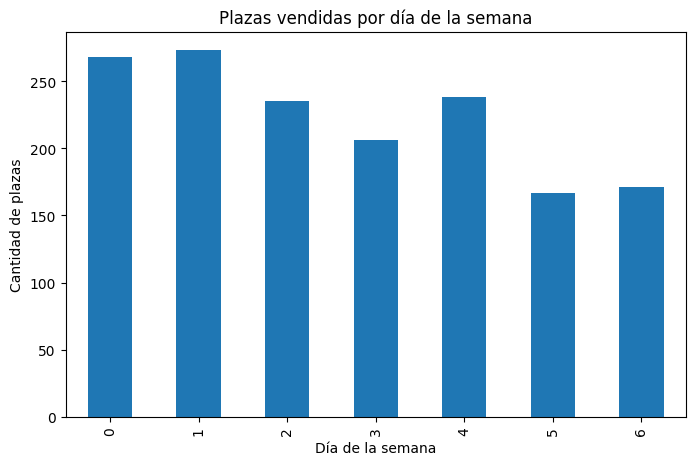

In [260]:
# Representar el volumen de plazas vendidas por día de la semana

compras_dia.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Plazas vendidas por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de plazas")

plt.show()

## 7.4 Evolución temporal de la demanda

In [261]:
# Analizar la evolución mensual de la demanda a lo largo del tiempo

demanda_mensual = (
    df.groupby(
        ["Año_Compra", "Mes_Compra"]
    )["Cantidad de Plazas"]
    .sum()
    .reset_index()
)

demanda_mensual.head()

,Año_Compra,Mes_Compra,Cantidad de Plazas
0,2025,1,168
1,2025,2,122
2,2025,3,76
3,2025,4,98
4,2025,5,123


## 7.5 Talleres con mayor ocupación

In [262]:
# Identificar los talleres con mayor volumen de asistentes

ocupacion_taller = (
    df.groupby("Taller")["Cantidad de Plazas"]
    .sum()
    .sort_values(
        ascending=False
    )
)

ocupacion_taller

Taller
Curso de Arroces                314
Paella Lovers                   247
Sushi                           220
Ramen                           159
Tapas Españolas                 144
Raíces                          124
Kimchi                          104
Taller de Pasta Fresca           75
Reposteria                       62
Taller de Principiantes          29
Cocas Miquel Ruiz                25
Curso Cocina Mexicana            19
Taller de Curry                  13
Esperando selección de curso     10
Croquetas                         6
NOBLE                             4
Clasicos Valencianos              3
Name: Cantidad de Plazas, dtype: int64

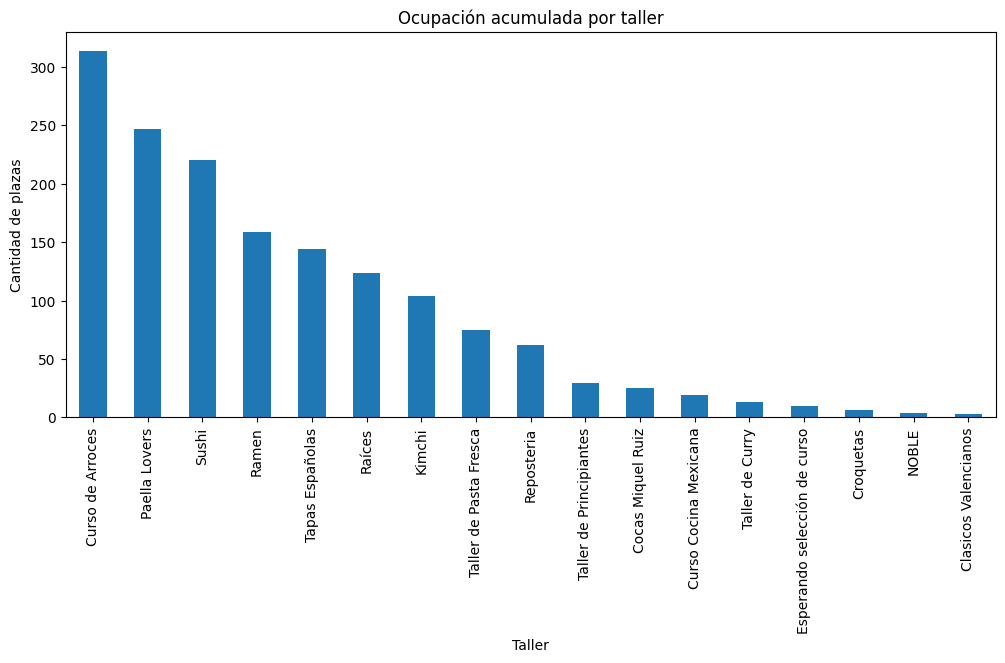

In [263]:
# Representar los talleres con mayor ocupación acumulada

ocupacion_taller.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Ocupación acumulada por taller")
plt.xlabel("Taller")
plt.ylabel("Cantidad de plazas")

plt.xticks(rotation=90)

plt.show()

# Conclusiones
El trabajo demuestra que es posible estimar la demanda futura de la empresa mediante técnicas de predicción temporal. Asimismo, el análisis de ocupación permitió identificar factores relevantes relacionados con el comportamiento de compra de los clientes, como la antelación de reserva y la estacionalidad de la demanda.

Aunque los modelos de ocupación presentan una capacidad predictiva moderada, los resultados obtenidos aportan información valiosa para la planificación de la actividad. A partir de estos hallazgos, se propone un modelo de optimización basado en programación matemática que permita diseñar un calendario de talleres alineado con la demanda esperada y maximizar la utilización de los recursos disponibles.


# 8. Exportación de resultados

Con el objetivo de facilitar la integración de los resultados en el dashboard final del proyecto, se exportan las métricas de rendimiento de los modelos evaluados.

In [264]:
resultados_demanda = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],
    "R²": [
        0.807,
        0.850,
        0.847
    ],
    "MAE": [
        0.338,
        0.172,
        0.194
    ],
    "RMSE": [
        0.514,
        0.453,
        0.457
    ]
})

resultados_demanda

,Modelo,R²,MAE,RMSE
0,Regresión Lineal,0.807,0.338,0.514
1,Random Forest,0.850,0.172,0.453
2,XGBoost,0.847,0.194,0.457


In [265]:
resultados_demanda.to_excel(
    "resultados_demanda.xlsx",
    index=False
)

print("Archivo exportado correctamente")

Archivo exportado correctamente
